In [ ]:
# this script will define 25 bins of transcripts based on expression

In [54]:
import pandas, re, numpy, scipy, os, glob
import sklearn, sklearn.preprocessing, sklearn.decomposition
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

In [4]:
input_file = '/Users/adrian/research/095/quant/DESeq2_TPM_values.tsv'

In [5]:
expression = pandas.read_csv(input_file, sep='\t', index_col=0)
print(expression.shape)
expression

(39546, 27)


,PN1_Rep1,PN1_Rep2,PN1_Rep3,PN2_Rep1,PN2_Rep2,PN2_Rep3,PN45_Rep1,PN45_Rep2,PN45_Rep3,PN5_Rep1,...,PN6_Rep3,PN73_Rep1,PN73_Rep2,PN73_Rep3,PN76_Rep1,PN76_Rep2,PN76_Rep3,PN78_Rep1,PN78_Rep2,PN78_Rep3
ENSG00000000003.15,14.562498,13.139604,11.529511,14.487337,12.769524,10.521004,11.262213,10.068717,11.115815,14.921048,...,12.045615,12.294504,13.421202,12.590818,14.614273,14.680828,11.533821,11.753062,12.482642,10.837772
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,126.090655,140.719691,121.123451,109.760983,88.862882,135.208131,113.942831,121.979434,111.163897,134.776159,...,122.332710,135.607627,151.374128,119.205893,120.315974,141.453030,122.297512,122.406449,134.536236,108.869043
ENSG00000000457.14,9.404964,7.996514,7.855294,10.133971,8.688212,7.671342,7.767095,6.870163,6.197656,7.473943,...,6.976369,6.758040,7.560432,8.064211,8.208867,9.056719,7.357067,8.265311,6.690425,6.646541
ENSG00000000460.17,22.917175,21.089529,26.299836,25.835933,20.748966,37.329524,25.285963,22.687589,27.884293,20.151603,...,30.033885,28.074722,32.115880,39.573679,27.176285,26.867481,37.137122,22.052300,23.166476,25.375199
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.585454,0.657605,0.765361,0.142214,0.656212,0.537985,0.563300,0.184360,0.685011,0.963708,...,0.449352,0.408898,0.666411,0.570158,0.788876,0.622595,0.712580,0.274456,0.355736,0.898923
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,0.265531,1.267744,0.192918,0.221620,2.204339,2.380327,0.174055,0.266047,2.378281,1.252130,...,1.147496,0.910221,0.886706,1.361524,1.209052,1.784110,1.146009,1.659220,1.617996,0.772327
ENSG00000291300.1,0.000000,0.000000,0.000000,0.051858,0.040324,0.029716,0.000000,0.050558,0.000000,0.099130,...,0.026226,0.025887,0.000000,0.000000,0.028936,0.105996,0.059876,0.177801,0.027442,0.000000


In [11]:
# filter and transform
groups = pandas.Series(expression.columns.str.split('_').str[0],
                       index=expression.columns, name='group')
groups
group_medians = expression.T.groupby(groups).median().T            # genes × conditions

substantial_expression = expression[group_medians.max(axis=1) >= 2]
high_expression        = expression[group_medians.max(axis=1) >= 100]
print(substantial_expression.shape, high_expression.shape)

(13223, 27) (1925, 27)


In [12]:
group_medians

group,PN1,PN2,PN45,PN5,PN55,PN6,PN73,PN76,PN78
ENSG00000000003.15,13.139604,12.769524,11.115815,14.350306,10.299185,12.045615,12.590818,14.614273,11.753062
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,126.090655,109.760983,113.942831,117.677191,117.826852,80.536770,135.607627,122.297512,122.406449
ENSG00000000457.14,7.996514,8.688212,6.870163,7.473943,6.868434,7.842292,7.560432,8.208867,6.690425
ENSG00000000460.17,22.917175,25.835933,25.285963,20.151603,26.101089,18.874488,32.115880,27.176285,23.166476
...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.657605,0.537985,0.563300,0.476015,0.334618,0.449352,0.570158,0.712580,0.355736
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,0.265531,2.204339,0.266047,1.214902,1.402495,0.937730,0.910221,1.209052,1.617996
ENSG00000291300.1,0.000000,0.040324,0.000000,0.056414,0.019138,0.026226,0.000000,0.059876,0.027442


In [15]:
transpose = substantial_expression.transpose()
pca_substantial_expression = numpy.log2(transpose + 1)

transpose = high_expression.transpose()
pca_high_expression = numpy.log2(transpose + 1)

In [23]:
scaled_data = sklearn.preprocessing.StandardScaler().fit_transform(pca_high_expression)
model = sklearn.decomposition.PCA(n_components=2)
new = model.fit_transform(scaled_data)
explained = model.explained_variance_ratio_
print(explained)

[0.35248959 0.26248331]


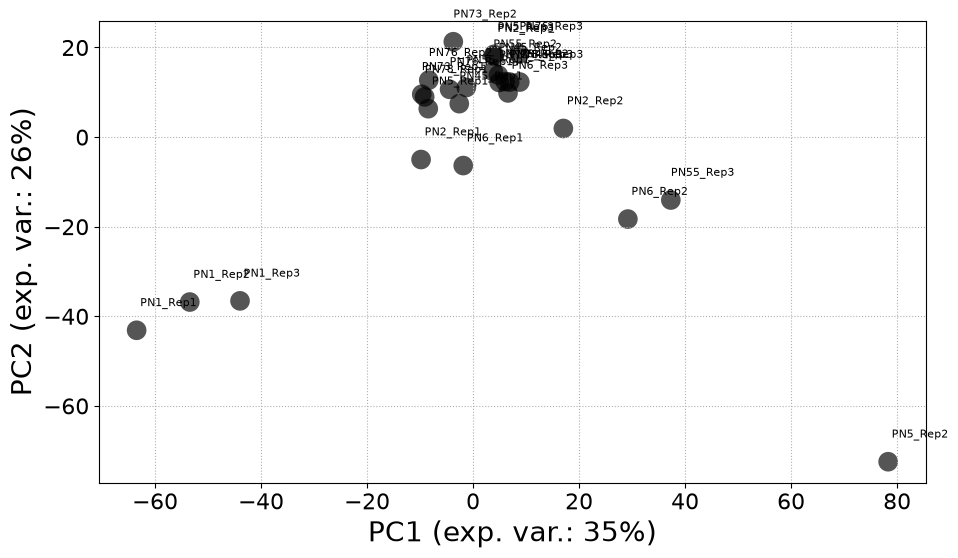

In [24]:
for i in range(len(new)):

    name = pca_high_expression.index[i]
        
    matplotlib.pyplot.scatter(new[i,0], new[i,1], s=200, c='black', marker='o', alpha=2/3, edgecolors='none')
    epsilon=6
    matplotlib.pyplot.text(new[i,0]+epsilon, new[i,1]+epsilon, name, size=8, va='center', ha='center')
    
matplotlib.pyplot.xlabel('PC1 (exp. var.: {}%)'.format(int(explained[0]*100)))
matplotlib.pyplot.ylabel('PC2 (exp. var.: {}%)'.format(int(explained[1]*100)))
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.show()


PN1_Rep1
17.319269275918913
PN1_Rep2
17.37821465022312
PN1_Rep3
17.65344531986133
PN2_Rep1
PN2_Rep2
PN2_Rep3
PN45_Rep1
PN45_Rep2
PN45_Rep3
PN5_Rep1
PN5_Rep2
PN5_Rep3
PN55_Rep1
PN55_Rep2
PN55_Rep3
PN6_Rep1
PN6_Rep2
PN6_Rep3
PN73_Rep1
PN73_Rep2
PN73_Rep3
PN76_Rep1
PN76_Rep2
PN76_Rep3
PN78_Rep1
PN78_Rep2
PN78_Rep3
[ 0.55  0.65  0.75  0.85  0.95  1.05  1.15  1.25  1.35  1.45  1.55  1.65
  1.75  1.85  1.95  2.05  2.15  2.25  2.35  2.45  2.55  2.65  2.75  2.85
  2.95  3.05  3.15  3.25  3.35  3.45  3.55  3.65  3.75  3.85  3.95  4.05
  4.15  4.25  4.35  4.45  4.55  4.65  4.75  4.85  4.95  5.05  5.15  5.25
  5.35  5.45  5.55  5.65  5.75  5.85  5.95  6.05  6.15  6.25  6.35  6.45
  6.55  6.65  6.75  6.85  6.95  7.05  7.15  7.25  7.35  7.45  7.55  7.65
  7.75  7.85  7.95  8.05  8.15  8.25  8.35  8.45  8.55  8.65  8.75  8.85
  8.95  9.05  9.15  9.25  9.35  9.45  9.55  9.65  9.75  9.85  9.95 10.05
 10.15 10.25 10.35 10.45 10.55 10.65 10.75 10.85 10.95 11.05 11.15 11.25
 11.35 11.45 11.55 11.65 11.75

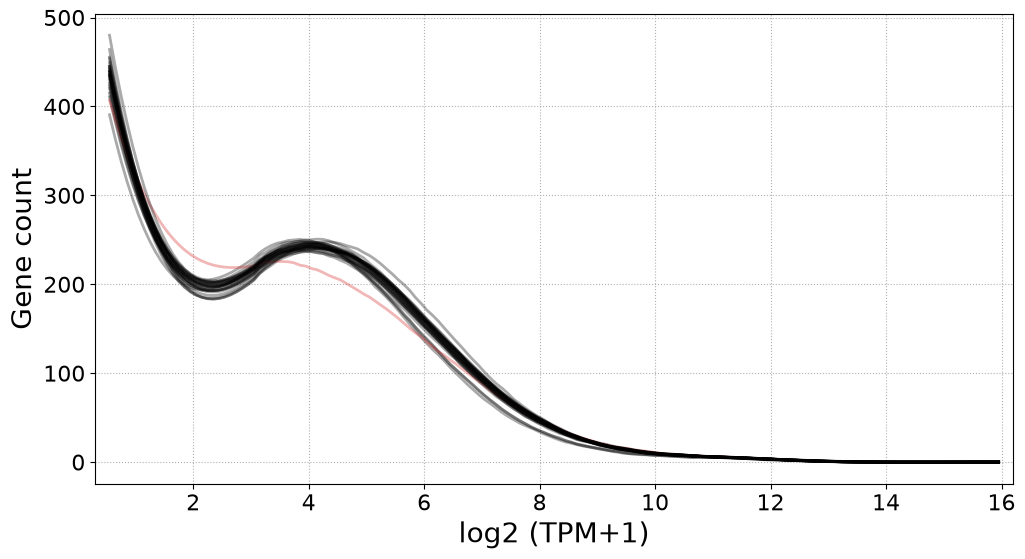

In [36]:
# expression
log2_tpm_PO = numpy.log2(expression + 1)
log2_tpm_PO.head()

found_max = 18
number_of_bins = int(found_max*10)

absolute_max = 0
working_samples = log2_tpm_PO.columns.to_list()

most_likely_expressions = []
all_hats = []
for i in range(len(working_samples)):

    name = working_samples[i]
    print(name)
    
    log2TPM = log2_tpm_PO.loc[:, name]
    if max(log2TPM) > absolute_max:
        absolute_max = max(log2TPM)
        print(absolute_max)
                
    hist, bin_edges = numpy.histogram(log2TPM, bins=number_of_bins, range=(0, found_max))
    half_bin = (bin_edges[1] - bin_edges[0])/2
    x = bin_edges + half_bin
    x = x[:-1]
  
    plotting_x = x[5:-20]
    plotting_hist = hist[5:-20]
    #print(plotting_x)
    
    #matplotlib.pyplot.plot(plotting_x, plotting_hist, 'o', alpha=1/5, mec='none', color=the_color)
    yhat = scipy.signal.savgol_filter(plotting_hist, 51, 3)

    if name == 'PN5_Rep2':
        the_color = 'tab:red'
    else:
        the_color = 'black'
    matplotlib.pyplot.plot(plotting_x, yhat, '-', lw=2, alpha=1/3, color=the_color)

print(plotting_x)
    
matplotlib.pyplot.xlim([numpy.min(plotting_x)-0.25, numpy.max(plotting_x)+0.25])

matplotlib.pyplot.xlabel('log2 (TPM+1)')
matplotlib.pyplot.ylabel('Gene count')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.tight_layout()

print(absolute_max)

In [37]:
log2_tpm_PO

,PN1_Rep1,PN1_Rep2,PN1_Rep3,PN2_Rep1,PN2_Rep2,PN2_Rep3,PN45_Rep1,PN45_Rep2,PN45_Rep3,PN5_Rep1,...,PN6_Rep3,PN73_Rep1,PN73_Rep2,PN73_Rep3,PN76_Rep1,PN76_Rep2,PN76_Rep3,PN78_Rep1,PN78_Rep2,PN78_Rep3
ENSG00000000003.15,3.960002,3.821670,3.647258,3.953017,3.783407,3.526194,3.616148,3.468416,3.598820,3.992863,...,3.705493,3.732758,3.850119,3.764560,3.964794,3.970930,3.647754,3.672772,3.753031,3.565326
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,6.989714,7.146896,6.932196,6.791306,6.489653,7.089669,6.844773,6.942273,6.809465,7.085086,...,6.946412,7.093894,7.251474,6.909364,6.922626,7.154342,6.946000,6.947274,7.082535,6.779641
ENSG00000000457.14,3.379200,3.169366,3.146540,3.476896,3.276230,3.116255,3.132099,2.976394,2.847527,3.083033,...,2.995732,2.955692,3.097684,3.180181,3.203024,3.330088,3.062997,3.211839,2.943063,2.934807
ENSG00000000460.17,4.579975,4.465291,4.770820,4.746094,4.442875,5.260384,4.716221,4.566059,4.852213,4.402695,...,4.955772,4.861693,5.049451,5.342472,4.816410,4.800511,5.253124,4.526839,4.594935,4.721110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.664896,0.729101,0.819963,0.191834,0.727887,0.621041,0.644595,0.244108,0.752758,0.973580,...,0.535408,0.494567,0.736745,0.650910,0.839054,0.698303,0.776171,0.349881,0.439076,0.925181
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,0.339743,1.181258,0.254495,0.288796,1.680027,1.757163,0.231500,0.340331,1.756289,1.171290,...,1.102655,0.933740,0.915869,1.239718,1.143427,1.477216,1.101656,1.411003,1.388463,0.825644
ENSG00000291300.1,0.000000,0.000000,0.000000,0.072940,0.057032,0.042246,0.000000,0.071155,0.000000,0.136363,...,0.037349,0.036872,0.000000,0.000000,0.041154,0.145346,0.083896,0.236096,0.039058,0.000000


In [41]:
log2_tpm_PO.head()


,PN1_Rep1,PN1_Rep2,PN1_Rep3,PN2_Rep1,PN2_Rep2,PN2_Rep3,PN45_Rep1,PN45_Rep2,PN45_Rep3,PN5_Rep1,...,PN6_Rep3,PN73_Rep1,PN73_Rep2,PN73_Rep3,PN76_Rep1,PN76_Rep2,PN76_Rep3,PN78_Rep1,PN78_Rep2,PN78_Rep3
ENSG00000000003.15,3.960002,3.821670,3.647258,3.953017,3.783407,3.526194,3.616148,3.468416,3.598820,3.992863,...,3.705493,3.732758,3.850119,3.764560,3.964794,3.970930,3.647754,3.672772,3.753031,3.565326
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000000419.14,6.989714,7.146896,6.932196,6.791306,6.489653,7.089669,6.844773,6.942273,6.809465,7.085086,...,6.946412,7.093894,7.251474,6.909364,6.922626,7.154342,6.946000,6.947274,7.082535,6.779641
ENSG00000000457.14,3.379200,3.169366,3.146540,3.476896,3.276230,3.116255,3.132099,2.976394,2.847527,3.083033,...,2.995732,2.955692,3.097684,3.180181,3.203024,3.330088,3.062997,3.211839,2.943063,2.934807
ENSG00000000460.17,4.579975,4.465291,4.770820,4.746094,4.442875,5.260384,4.716221,4.566059,4.852213,4.402695,...,4.955772,4.861693,5.049451,5.342472,4.816410,4.800511,5.253124,4.526839,4.594935,4.721110


39546 genes -> 40 sequential chunks of 1000 (last chunk has 546 genes)


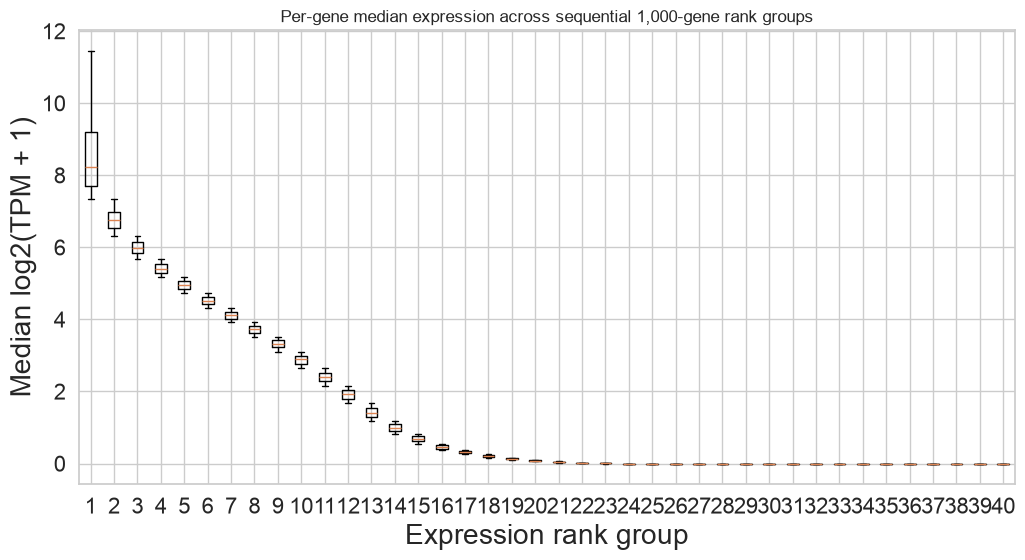

Wrote 39546 gene-group associations to expression_rank_groups.txt
Wrote 40 BED files to expression_rank_bed_files/


In [52]:
FAI_PATH = "/Users/adrian/research/095/ref/human_nac.nascent.fa.fai"
GROUP_TXT_PATH = "expression_rank_groups.txt"
BED_OUT_DIR = "expression_rank_bed_files"
chunk_size = 1000

os.makedirs(BED_OUT_DIR, exist_ok=True)

# gene_id -> transcript length, from the .fai index
fai_df = pandas.read_csv(
    FAI_PATH, sep="\t", header=None,
    names=["gene_id", "length", "offset", "linebases", "linewidth"]
)
length_lookup = dict(zip(fai_df["gene_id"], fai_df["length"]))

# rank genes by median log2(TPM+1) across all samples, descending
gene_medians = log2_tpm_PO.median(axis=1).sort_values(ascending=False)
n_genes = len(gene_medians)
n_chunks = int(numpy.ceil(n_genes / chunk_size))
print(f"{n_genes} genes -> {n_chunks} sequential chunks of {chunk_size} "
      f"(last chunk has {n_genes - (n_chunks - 1) * chunk_size} genes)")

data_for_plot = []
labels = []
group_gene_rows = []

for i in range(n_chunks):
    group_id = i + 1
    chunk_ids = gene_medians.index[i * chunk_size : (i + 1) * chunk_size]
    values = gene_medians.iloc[i * chunk_size : (i + 1) * chunk_size].values
    data_for_plot.append(values)
    labels.append(str(group_id))

    for gene_id in chunk_ids:
        group_gene_rows.append((group_id, gene_id))

    missing = [gid for gid in chunk_ids if gid not in length_lookup]
    if missing:
        print(f"WARNING: group {group_id} has {len(missing)} gene IDs not found in .fai; skipping them in BED file.")

    bed_rows = [(gid, 0, length_lookup[gid]) for gid in chunk_ids if gid in length_lookup]
    bed_df = pandas.DataFrame(bed_rows, columns=["chrom", "start", "end"])
    bed_path = os.path.join(BED_OUT_DIR, f"expression_group_{group_id:02d}.bed")
    bed_df.to_csv(bed_path, sep="\t", header=False, index=False)

# boxplot
fig, ax = matplotlib.pyplot.subplots()
ax.boxplot(data_for_plot, showfliers=False)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_xlabel("Expression rank group")
ax.set_ylabel("Median log2(TPM + 1)")
ax.set_title("Per-gene median expression across sequential 1,000-gene rank groups")
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

# group -> gene text file
group_gene_df = pandas.DataFrame(group_gene_rows, columns=["group", "gene_id"])
group_gene_df.to_csv(GROUP_TXT_PATH, sep="\t", index=False)
print(f"Wrote {len(group_gene_df)} gene-group associations to {GROUP_TXT_PATH}")
print(f"Wrote {n_chunks} BED files to {BED_OUT_DIR}/")

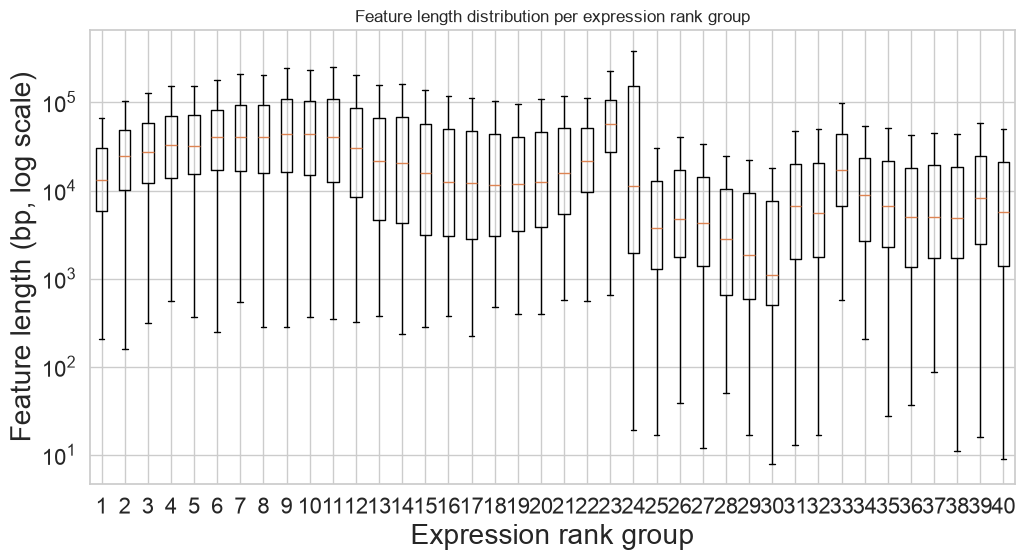

In [56]:
bed_files = sorted(glob.glob(os.path.join(BED_OUT_DIR, "expression_group_*.bed")))

data_for_plot = []
labels = []
for bed_path in bed_files:
    bed_df = pandas.read_csv(bed_path, sep="\t", header=None, names=["chrom", "start", "end"])
    feature_lengths = (bed_df["end"] - bed_df["start"]).values
    data_for_plot.append(feature_lengths)
    group_id = os.path.basename(bed_path).split("_")[-1].replace(".bed", "")
    labels.append(str(int(group_id)))

fig, ax = matplotlib.pyplot.subplots()
ax.boxplot(data_for_plot, showfliers=False)
ax.set_yscale("log")
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_xlabel("Expression rank group")
ax.set_ylabel("Feature length (bp, log scale)")
ax.set_title("Feature length distribution per expression rank group")
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()